**ETAPA 1 – Introdução**

**Objetivo**

Nesta etapa será implementado o algoritmo Random Forest para resolver o Problema B, cujo objetivo é prever se um candidato convocado na Lista de Espera do SISU efetivará sua matrícula.

O algoritmo será treinado utilizando a base previamente processada, balanceada com SMOTE e padronizada. Posteriormente, será realizada a busca pelos melhores hiperparâmetros e a avaliação do desempenho do modelo utilizando o conjunto de teste.

**O que é Random Forest?**

O **Random Forest (Floresta Aleatória)** é um algoritmo de aprendizado supervisionado baseado na construção de múltiplas árvores de decisão.

Cada árvore é treinada utilizando uma amostra aleatória dos dados (Bootstrap) e um subconjunto aleatório de atributos, reduzindo a correlação entre as árvores e aumentando a capacidade de generalização do modelo.

A classificação final é obtida por meio da votação da maioria das árvores, tornando o algoritmo mais robusto e menos suscetível ao overfitting quando comparado a uma única Árvore de Decisão.

**ETAPA 2 – Importação das Bibliotecas**

In [33]:
import pandas as pd
import numpy as np

import time

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

**ETAPA 3 – Carregamento das Bases**

In [34]:
# MONTA O GOOGLE DRIVE PARA ACESSAR OS ARQUIVOS DE DADOS ARMAZENADOS NELE.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# DEFINE O DIRETÓRIO NO GOOGLE DRIVE CONTENDO AS BASES DE DADOS UTILIZADOS NO SEGUNDO TRABALHO.

import pandas as pd
import numpy as np

PATH = '/content/drive/MyDrive/PP_CD'

In [36]:
# CARREGAMENTO DAS BASES

treino = pd.read_pickle(f'{PATH}/base_treino.pkl')
teste = pd.read_pickle(f'{PATH}/base_teste.pkl')

print("Treino:", treino.shape)
print("Teste :", teste.shape)

display(treino.head())
display(teste.head())

Treino: (99362, 23)
Teste : (15809, 23)


,CODIGO_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,SEXO,...,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_CANDIDATO,NOTA_CORTE,MESMA_UF,MESMO_MUNICIPIO,IDADE,MATRICULA
0,0.256133,-0.451890,-0.673736,0.128932,-0.669029,-0.061029,2.090035,0.743401,2.939621,1.400306,...,1.569866,2.097158,2.208128,1.552405,2.055747,1.402944,-1.644456,-0.658020,0.064502,1
1,-0.242948,-0.451890,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,0.548206,-0.206526,-0.714130,...,0.094882,0.162337,0.146458,0.496112,0.233991,0.855121,-1.644456,-0.658020,-0.263192,0
2,-0.201938,-0.451890,1.329400,0.128932,-0.669029,-1.015803,-0.961108,2.207358,-0.206526,-0.714130,...,0.751608,0.382288,0.099788,1.420368,0.708437,0.736849,0.608104,-0.658020,0.064502,0
3,-0.243816,1.100101,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,0.450609,-0.206526,-0.714130,...,-0.593620,0.605967,0.324132,-1.088327,-0.295296,-0.248409,0.608104,-0.658020,-0.427039,0
4,-0.202583,-0.451890,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,1.133789,-0.206526,-0.714130,...,-2.006374,-1.130028,-1.396110,0.364075,-0.928455,-0.073229,0.608104,1.519711,-0.590887,1


,CODIGO_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,SEXO,...,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_CANDIDATO,NOTA_CORTE,MESMA_UF,MESMO_MUNICIPIO,IDADE,MATRICULA
12493,0.330668,-0.451890,-0.673736,0.128932,1.763425,0.893744,0.610693,-0.622960,-0.206526,1.400306,...,-2.539964,-0.291233,-0.378375,-1.748510,-1.242130,-1.249665,0.608104,-0.658020,-0.427039,0
7442,0.284203,-0.451890,-0.673736,0.128932,-0.669029,1.848517,-0.498814,-1.110945,-0.206526,-0.714130,...,0.933002,-0.447808,0.485430,0.496112,0.286654,1.711023,0.608104,-0.658020,-0.427039,0
39443,-0.201938,-0.451890,1.329400,0.128932,1.763425,0.893744,0.610693,0.157818,-0.206526,-0.714130,...,0.743663,0.905448,-0.050866,-0.032035,0.454205,0.091552,0.608104,-0.658020,-0.263192,0
21195,0.203258,1.100101,0.327832,0.128932,-0.669029,-1.015803,-0.961108,0.157818,-0.206526,1.400306,...,-1.127210,0.520223,-0.868001,-1.616474,-1.109687,-1.066258,0.608104,1.519711,-0.427039,0
44439,-0.243626,-0.451890,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,1.914567,-0.206526,1.400306,...,1.364640,1.039655,0.912830,1.156295,1.161455,1.654229,0.608104,-0.658020,-0.427039,0


**Interpretação**

As bases previamente processadas foram carregadas com sucesso. O conjunto de treinamento corresponde aos dados balanceados por meio da técnica SMOTE, enquanto o conjunto de teste permaneceu inalterado para garantir uma avaliação imparcial do modelo.

**ETAPA 4 – Separação entre Atributos e Variável-Alvo**

In [37]:
# SEPARAÇÃO ENTRE X E y

X_train = treino.drop(columns=['MATRICULA'])
y_train = treino['MATRICULA']

X_test = teste.drop(columns=['MATRICULA'])
y_test = teste['MATRICULA']

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train: (99362, 22)
y_train: (99362,)
X_test : (15809, 22)
y_test : (15809,)


**Interpretação**

A variável **MATRICULA** foi separada dos demais atributos, passando a representar a variável-alvo (y). As demais colunas foram utilizadas como atributos preditores (X), que servirão de entrada para o treinamento do modelo.

**ETAPA 5 – Treinamento do Modelo Base**

**Objetivo**

Inicialmente será treinado um modelo utilizando os parâmetros padrão da biblioteca Scikit-Learn. Esse modelo servirá como referência para comparação com os modelos ajustados durante a etapa de otimização de hiperparâmetros.

In [38]:
# TREINAMENTO DO MODELO BASE

inicio = time.time()

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

fim = time.time()

tempo_treinamento = fim - inicio

print(f"Tempo de treinamento: {tempo_treinamento:.2f} segundos")

Tempo de treinamento: 50.25 segundos


**Interpretação**

O modelo Random Forest foi treinado utilizando os parâmetros padrão da biblioteca Scikit-Learn. O tempo de treinamento foi registrado para posterior comparação com os modelos ajustados durante a etapa de otimização de hiperparâmetros.

**5.1 Separação entre Treino e Validação**

**Objetivo**

Como a estratégia adotada neste projeto foi Holdout, o conjunto de treinamento foi novamente dividido em dois subconjuntos: um destinado ao treinamento do modelo e outro reservado para validação.

O conjunto de validação será utilizado exclusivamente durante a busca pelos melhores hiperparâmetros do algoritmo Random Forest. Dessa forma, o conjunto de teste permanece completamente isolado e será utilizado apenas na avaliação final do modelo, evitando vazamento de informação (data leakage) e proporcionando uma estimativa mais confiável da capacidade de generalização do algoritmo.

In [39]:
# ETAPA 5.1 - SEPARAÇÃO ENTRE TREINO E VALIDAÇÃO

from sklearn.model_selection import train_test_split

X_train_fit, X_valid, y_train_fit, y_valid = train_test_split(

    X_train,
    y_train,

    test_size=0.20,

    stratify=y_train,

    random_state=42

)

print("Treino:", X_train_fit.shape)
print("Validação:", X_valid.shape)

print("\nClasses (Treino)")
print(y_train_fit.value_counts())

print("\nClasses (Validação)")
print(y_valid.value_counts())

Treino: (79489, 22)
Validação: (19873, 22)

Classes (Treino)
MATRICULA
1    39745
0    39744
Name: count, dtype: int64

Classes (Validação)
MATRICULA
0    9937
1    9936
Name: count, dtype: int64


**Interpretação**

O conjunto de treinamento foi dividido em 80% para treinamento e 20% para validação, preservando a proporção das classes da variável-alvo por meio da amostragem estratificada.

Essa divisão será utilizada apenas durante a busca dos hiperparâmetros, enquanto o conjunto de teste permanecerá reservado para a avaliação final do modelo.

**5.2 Busca de Hiperparâmetros**

**Objetivo**

Nesta etapa foi realizada uma busca manual pelos principais hiperparâmetros do algoritmo **Random Forest**

Como a metodologia escolhida foi Holdout, o desempenho de cada configuração foi avaliado utilizando o conjunto de validação, evitando que o conjunto de teste influenciasse a escolha dos melhores parâmetros.

Os hiperparâmetros avaliados foram:

n_estimators: quantidade de árvores da floresta;
max_depth: profundidade máxima das árvores;
max_features: quantidade de atributos considerados em cada divisão;
class_weight: estratégia para ponderação das classes.

Como métrica de comparação foi utilizado o Recall da classe positiva, por ser a métrica prioritária para o Problema B. O objetivo foi maximizar a capacidade do modelo em identificar corretamente os candidatos que efetivarão a matrícula, conforme proposto no trabalho.

Embora o conjunto de treinamento já tenha sido balanceado utilizando a técnica SMOTE, também foi avaliado o parâmetro class_weight para verificar se a ponderação automática das classes poderia proporcionar ganhos adicionais de desempenho.

In [40]:
# ETAPA 5.2 - BUSCA MANUAL DE HIPERPARÂMETROS

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
import pandas as pd
import time

inicio_busca = time.time()

resultados = []

# Total de combinações
total_modelos = 16
contador = 1

for n_estimators in [100, 200]:

    for max_depth in [10, 20]:

        for max_features in ['sqrt', 'log2']:

            for min_samples_leaf in [1, 2]:

                print(f"Treinando modelo {contador}/{total_modelos}...")

                inicio_fit = time.time()

                modelo = RandomForestClassifier(

                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    max_features=max_features,
                    min_samples_leaf=min_samples_leaf,
                    criterion='gini',
                    random_state=42,
                    n_jobs=-1

                )

                # Treinamento
                modelo.fit(X_train_fit, y_train_fit)

                fim_fit = time.time()

                # Predição no conjunto de validação
                y_pred = modelo.predict(X_valid)

                # Armazena os resultados
                resultados.append([

                    n_estimators,
                    max_depth,
                    max_features,
                    min_samples_leaf,
                    recall_score(y_valid, y_pred),
                    fim_fit - inicio_fit

                ])

                contador += 1

fim_busca = time.time()


# RESULTADOS

resultados_rf = pd.DataFrame(

    resultados,

    columns=[

        'n_estimators',
        'max_depth',
        'max_features',
        'min_samples_leaf',
        'recall',
        'tempo_fit'

    ]

)

resultados_rf = resultados_rf.sort_values(

    by='recall',
    ascending=False

).reset_index(drop=True)

display(resultados_rf)

print("\nTempo total da busca:",
      round(fim_busca - inicio_busca, 2),
      "segundos")

Treinando modelo 1/16...
Treinando modelo 2/16...
Treinando modelo 3/16...
Treinando modelo 4/16...
Treinando modelo 5/16...
Treinando modelo 6/16...
Treinando modelo 7/16...
Treinando modelo 8/16...
Treinando modelo 9/16...
Treinando modelo 10/16...
Treinando modelo 11/16...
Treinando modelo 12/16...
Treinando modelo 13/16...
Treinando modelo 14/16...
Treinando modelo 15/16...
Treinando modelo 16/16...


,n_estimators,max_depth,max_features,min_samples_leaf,recall,tempo_fit
0,200,20,sqrt,1,0.922403,52.901493
1,200,20,log2,1,0.922403,51.710499
2,100,20,log2,1,0.919988,26.412297
3,100,20,sqrt,1,0.919988,31.912783
4,200,20,sqrt,2,0.915862,52.842338
5,200,20,log2,2,0.915862,49.947986
6,100,20,log2,2,0.914251,25.003374
7,100,20,sqrt,2,0.914251,30.395896
8,200,10,log2,1,0.869163,32.523883
9,200,10,sqrt,1,0.869163,32.486006



Tempo total da busca: 532.27 segundos


**Interpretação**

Foram avaliadas diferentes combinações dos principais hiperparâmetros do algoritmo Random Forest utilizando uma estratégia de busca manual.

Cada configuração foi treinada utilizando o conjunto de treinamento e avaliada no conjunto de validação por meio do Recall da classe positiva, permitindo identificar a combinação de hiperparâmetros com maior capacidade de identificar corretamente os candidatos que efetivarão a matrícula.

Além do desempenho preditivo, também foi registrado o tempo necessário para treinar cada configuração.

**5.3 Significado dos Hiperparâmetros**

**n_estimators:** quantidade de árvores que compõem a floresta.

**max_depth:** profundidade máxima permitida para cada árvore.

**max_features:** quantidade de atributos considerados na divisão de cada nó.

**class_weight:** estratégia utilizada para ponderar as classes durante o treinamento.

**recall:** métrica utilizada para comparar as diferentes configurações de hiperparâmetros, representando a proporção de candidatos que efetivamente realizaram a matrícula e foram corretamente identificados pelo modelo.

**tempo_fit:** tempo gasto para treinar cada configuração avaliada.

**5.4 Melhor Configuração Encontrada**

In [41]:
# ETAPA 5.3 - MELHOR CONFIGURAÇÃO ENCONTRADA

melhor_rf = resultados_rf.iloc[0]

print("========== MELHOR RANDOM FOREST ==========\n")

print("n_estimators     :", melhor_rf['n_estimators'])
print("max_depth        :", melhor_rf['max_depth'])
print("max_features     :", melhor_rf['max_features'])
print("min_samples_leaf :", melhor_rf['min_samples_leaf'])

print("\nRecall      :", round(melhor_rf['recall'], 4))
print("Tempo Fit   :", round(melhor_rf['tempo_fit'], 2), "segundos")
print("Tempo Busca :", round(fim_busca - inicio_busca, 2), "segundos")

========== MELHOR RANDOM FOREST ==========

n_estimators     : 200
max_depth        : 20
max_features     : sqrt
min_samples_leaf : 1

Recall      : 0.9224
Tempo Fit   : 52.9 segundos
Tempo Busca : 532.27 segundos


**Interpretação**

A busca manual permitiu identificar a configuração de hiperparâmetros que apresentou o maior Recall no conjunto de validação. Essa configuração será utilizada para treinar o modelo definitivo utilizando todo o conjunto de treinamento balanceado. Somente após esse treinamento será realizada a avaliação no conjunto de teste, garantindo que o desempenho reportado represente a capacidade de generalização do modelo em dados nunca vistos.

Essa configuração será utilizada para treinar o modelo definitivo utilizando todo o conjunto de treinamento balanceado. Somente após esse treinamento será realizada a avaliação no conjunto de teste, garantindo que o desempenho reportado represente a capacidade de generalização do modelo em dados nunca vistos.

**ETAPA 6 – Avaliação do Modelo**

**Objetivo**

Após a definição dos melhores hiperparâmetros e o treinamento do modelo definitivo, realizou-se sua avaliação utilizando o conjunto de teste, que permaneceu isolado durante todas as etapas de treinamento e otimização.

Foram utilizadas diferentes métricas de classificação para analisar o desempenho do Random Forest, incluindo **Recall, Precision, F1-Score, Accuracy, AUC-ROC, Matriz de Confusão e Importância das Variáveis.**

In [47]:
# ETAPA 5.4 - TREINAMENTO DO MODELO FINAL

import time
from sklearn.ensemble import RandomForestClassifier

inicio = time.time()

rf = RandomForestClassifier(

    n_estimators=int(melhor_rf["n_estimators"]),
    max_depth=int(melhor_rf["max_depth"]),
    max_features=melhor_rf["max_features"],
    min_samples_leaf=int(melhor_rf["min_samples_leaf"]),

    criterion="gini",
    random_state=42,
    n_jobs=-1

)

# Agora utiliza TODO o conjunto de treinamento
rf.fit(X_train, y_train)

fim = time.time()

tempo_treinamento = fim - inicio

print(f"Tempo de treinamento: {tempo_treinamento:.2f} segundos")

Tempo de treinamento: 75.26 segundos


**6.1 Predições do Modelo**

In [69]:
# ETAPA 6.1 - PREDIÇÕES

# Probabilidade da classe positiva
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Limiar de decisão
threshold = 0.45

# Predições finais
y_pred_rf = (y_prob_rf >= threshold).astype(int)

**Interpretação**

Após o treinamento do modelo utilizando os melhores hiperparâmetros encontrados, foram realizadas as previsões para o conjunto de teste. As probabilidades da classe positiva foram convertidas em classes utilizando um limiar de decisão igual a 0,45, definido para aumentar o Recall da classe positiva.

Além das classes previstas (y_pred_rf), também foram obtidas as probabilidades (y_prob_rf), utilizadas posteriormente no cálculo da Curva ROC e da métrica AUC-ROC.

**6.2 Accuracy**

In [71]:
# ETAPA 6.2 - ACURÁCIA

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8151


A acurácia corresponde à proporção de classificações corretas realizadas pelo modelo em relação ao total de candidatos avaliados. Utilizando o limiar de decisão de 0,45, o Random Forest alcançou uma acurácia de aproximadamente 82%, indicando bom desempenho geral. Entretanto, como o Problema B apresenta foco na identificação dos candidatos que efetivarão a matrícula, a acurácia é utilizada apenas como métrica complementar, sendo o Recall da classe positiva a principal métrica de avaliação.

**6.3 Precision, Recall e F1-Score**

In [72]:
# ETAPA 6.3 - PRECISION, RECALL E F1-SCORE

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Precision : 0.5543
Recall    : 0.7014
F1-Score  : 0.6193


**Acurácia:** É a porcentagem de previsões corretas realizadas pelo modelo.

**Precision:** Entre todos os candidatos que o modelo previu como classe 1, quantos realmente pertenciam à classe 1.

**Recall:** Entre todos os candidatos que realmente pertenciam à classe 1, quantos o modelo conseguiu encontrar.

**F1-score:** É uma média harmônica entre Precision e Recall.

Como o objetivo principal deste trabalho é identificar corretamente os candidatos que efetivarão a matrícula, o Recall da classe positiva foi considerado a principal métrica de avaliação do modelo.

**ETAPA 6.4 - ÁREA SOB A CURVA ROC (AUC-ROC)**

In [73]:
# ETAPA 6.4 - ÁREA SOB A CURVA ROC (AUC-ROC)

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob_rf)

print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.8759


O Random Forest apresentou AUC-ROC igual a 0,8759, indicando boa capacidade de discriminar candidatos que efetivarão a matrícula daqueles que não efetivarão. Quanto mais próximo de 1, melhor é a capacidade discriminativa do modelo.

**ETAPA 6.5 - MATRIZ DE CONFUSÃO**

Matriz de Confusão:
[[10509  1911]
 [ 1012  2377]]


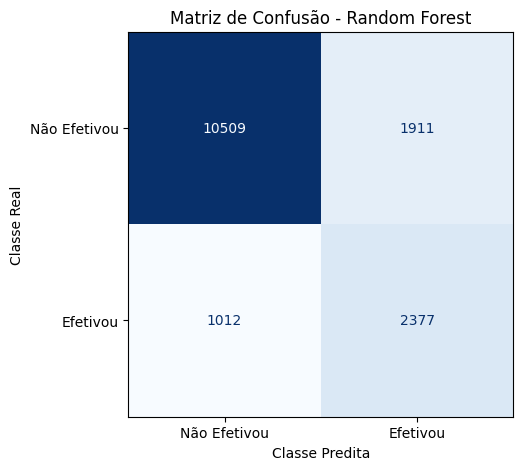

In [74]:
# ETAPA 6.5 - MATRIZ DE CONFUSÃO

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)

# Exibe os valores da matriz
print("Matriz de Confusão:")
print(cm)

# Gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Efetivou", "Efetivou"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    values_format='d',
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

**Verdadeiro Negativo (10509):** O candidato não efetivou a matrícula e o modelo classificou corretamente como não efetivou.

**Falso Positivo (1911):** O candidato não efetivou a matrícula, porém o modelo previu que efetivaria.

**Falso Negativo (1012):** O candidato efetivou a matrícula, porém o modelo previu que não efetivaria.

**Verdadeiro Positivo (2377):** O candidato efetivou a matrícula e o modelo classificou corretamente como efetivou.

A matriz de confusão mostra que o Random Forest classificou corretamente 10.509 candidatos que não efetivaram a matrícula (Verdadeiros Negativos) e 2.377 candidatos que efetivaram a matrícula (Verdadeiros Positivos). Além disso, ocorreram 1.911 falsos positivos, em que o modelo previu efetivação para candidatos que não efetivaram, e 1.012 falsos negativos, correspondentes aos candidatos que efetivaram a matrícula, mas não foram identificados pelo modelo. Considerando o objetivo do Problema B, observa-se que o modelo apresentou bom desempenho na identificação da classe positiva, alcançando Recall superior a 70% após o ajuste do limiar de decisão.

**ETAPA 6.6 - CURVA ROC**

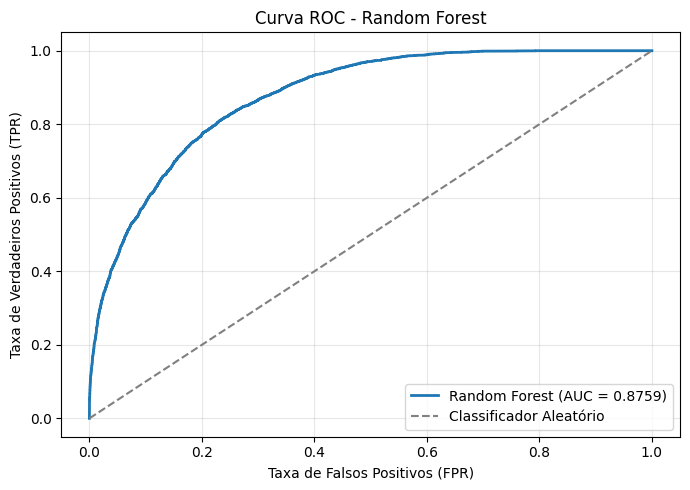

In [76]:
# ETAPA 6.6 - CURVA ROC

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcula a Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

# Gera o gráfico
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc:.4f})"
)

# Linha de referência (classificador aleatório)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Classificador Aleatório"
)

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC - Random Forest")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

A Curva ROC do Random Forest apresentou AUC igual a 0,8759, indicando boa capacidade de distinguir candidatos que efetivarão a matrícula daqueles que não efetivarão. A curva permaneceu significativamente acima da linha de referência de um classificador aleatório, evidenciando que o modelo possui elevado poder discriminativo.

**ETAPA 6.7 - IMPORTÂNCIA DAS FEATURES**

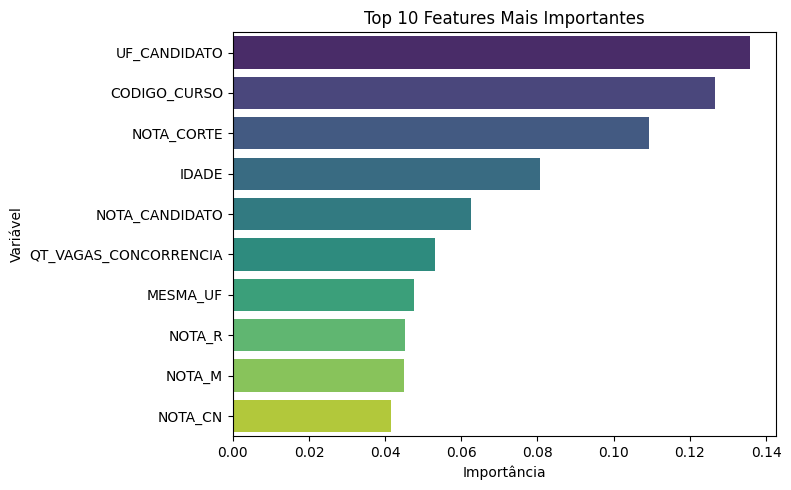

In [82]:
# ETAPA 6.7 - IMPORTÂNCIA DAS FEATURES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cria DataFrame com as importâncias
importancias = pd.DataFrame({

    'Feature': X_train.columns,
    'Importancia': rf.feature_importances_

})

# Ordena da maior para a menor
importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)


# Gráfico
plt.figure(figsize=(8,5))

sns.barplot(
    data=importancias.head(10),
    x='Importancia',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Features Mais Importantes')
plt.xlabel('Importância')
plt.ylabel('Variável')

plt.tight_layout()
plt.show()

A análise de importância das variáveis mostrou que UF_CANDIDATO, CODIGO_CURSO e NOTA_CORTE foram os atributos mais relevantes para as decisões do Random Forest. Em seguida destacaram-se IDADE, NOTA_CANDIDATO, QT_VAGAS_CONCORRENCIA e a feature derivada MESMA_UF, indicando que fatores geográficos, acadêmicos e características do processo seletivo influenciam conjuntamente a efetivação da matrícula. Além disso, diversas notas do ENEM também figuraram entre as variáveis mais importantes, evidenciando que o desempenho acadêmico exerce influência significativa sobre a variável-alvo.